# AAV5 — ProfileMLP sur le log enrichment, avant/après tri

Entraîne un `ProfileMLP` (même archi/entraînement que `AAV9_profile_model.ipynb` /
`ProfileMLP_train_Production1_test_Production2.ipynb`, one-hot 7×20=140 → MLP → 1 scalaire,
perte MSE non pondérée) sur **4 cibles de log enrichment réel** — les mêmes que
`AAV5_SEL_potts_regression.ipynb` :

| nom | cible (log2 enrichment) |
|---|---|
| `viab`     | `log2_enrichissement_virus_sur_plasmide` |
| `sel_org1` | `log2_enrichissement_organoide_1_adn_sur_virus` |
| `sel_org2` | `log2_enrichissement_organoide_2_adn_sur_virus` |
| `sel_org3` | `log2_enrichissement_organoide_3_adn_sur_virus` |

... sur **3 CSV** (12 modèles au total) :

- `brut` — `AAV5_organoides.csv` (5 595 543 variants), aucun filtre.
- `trié` — `AAV5_organoides_sorted.csv` (`AAV5_SEL_sorting.ipynb` §5 : hamming≤2 du 7m8 retiré +
  `10 ≤ compte_plasmide ≤ 500`, 3 822 400 variants). Filtre sur l'axe **viabilité**.
  `compte_virus` n'est jamais filtré par ce tri.
- `trié_organoïde` — `AAV5_organoides_sorted_organoide.csv` (`AAV5_SEL_sorting.ipynb` §8 :
  hamming≤2 du 7m8 retiré + **au moins 1 count sur au moins un des 3 réplicats organoïde ADN**,
  union). Filtre indépendant du précédent, pas empilé dessus — isole l'effet de "au moins une
  mesure organoïde" plutôt que "profondeur plasmide correcte".

L'objectif : voir si un MLP entraîné sur chaque CSV nettoyé généralise mieux sur held-out, et si
l'effet diffère entre `viab` (filtré directement par `trié`, pas par `trié_organoïde`) et les 3
cibles de sélectivité (jamais filtrées directement par `trié`, filtrées par construction par
`trié_organoïde` — cf. session : ~90-98% des lignes brutes ont `count=0` sur chaque réplicat
organoïde, `AAV5_SEL_analysis.ipynb` §1b).

Pour chaque (CSV, cible) : scatter held-out **log enrichment prédit vs réel** (hexbin, avec
Pearson r + droite y=x), et **recovery top-k%** (`precision_at_k` / `plot_topk_recovery`, mêmes
helpers que le reste du projet). Terminologie du projet respectée : la cible réelle et la
sortie du MLP sont des **log enrichment**, jamais un "score".

**Non pondéré** (contrairement à `AAV5_SEL_potts_regression.ipynb`, qui pondère par
`1/(1/n_num + 1/n_den)`) : la perte MSE du MLP traite tous les variants held-out à égalité,
comme les autres notebooks `ProfileMLP` du projet — piste ouverte si le bruit de comptage doit
être incorporé plus tard.

### 0. Setup

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

# robust lib path: walk up to Modelization_V2/ (a hardcoded ../../lib would silently resolve
# to Modelization_V1's pip-installed copy instead -- cf. AAV5_SEL_potts_regression.ipynb)
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must precede jax init (analysisV1 imports jax)

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_topk_recovery

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


### 1. Chargement des deux CSV + définition des 4 cibles

In [2]:
viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_cols = [f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)]
targets = {
    "viab":     viab_col,
    "sel_org1": sel_cols[0],
    "sel_org2": sel_cols[1],
    "sel_org3": sel_cols[2],
}
use_cols = ["sequence"] + list(targets.values())
dtypes = {"sequence": "string", **{c: "float32" for c in targets.values()}}

datasets = {}
for tag, fname in [("brut", "AAV5_organoides.csv"),
                    ("trié", "AAV5_organoides_sorted.csv"),
                    ("trié_organoïde", "AAV5_organoides_sorted_organoide.csv")]:
    p = Path(fname)
    if not p.exists():
        p = _root / "notebooks/notebooks/Selectivity/AAV5" / fname
    assert p.exists(), p
    df = pd.read_csv(p, usecols=use_cols, dtype=dtypes)
    df["sequence"] = df["sequence"].astype("string")
    datasets[tag] = df
    print(f"{tag:15s} {fname:38s} {len(df):,} variants")

L, A = 7, 20
assert list(AA_LABELS) == sorted(set("".join(datasets["brut"]["sequence"].head(200_000))))

brut            AAV5_organoides.csv                    5,595,543 variants


trié            AAV5_organoides_sorted.csv             3,822,400 variants


trié_organoïde  AAV5_organoides_sorted_organoide.csv   587,931 variants


### 2. Encodage des séquences

Indices bruts (0..19) une fois par CSV -- le one-hot (140 features) n'est fait qu'à la volée
sur les sous-échantillons `fit`/`held-out` de chaque combinaison (cf. §4), pour ne jamais
matérialiser un one-hot du CSV brut entier (5.6M × 140 float32 ≈ 3.1 Go, inutile puisqu'on
sous-échantillonne de toute façon).

In [3]:
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

def encode(df):
    return lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)

seq_matrices = {tag: encode(df) for tag, df in datasets.items()}
for tag, S in seq_matrices.items():
    print(f"{tag}: seq_matrix {S.shape}")

brut: seq_matrix (5595543, 7)
trié: seq_matrix (3822400, 7)
trié_organoïde: seq_matrix (587931, 7)


### 3. ProfileMLP -- même architecture/entraînement que AAV9_profile_model.ipynb

In [4]:
class ProfileMLP(nnx.Module):
    """MLP over the one-hot encoded per-position sequence (L=7 x A=20 -> 140 indicator
    features) -> scalar log enrichment. Linear + BatchNorm + Dropout + gelu, twice, then a
    linear readout -- identical architecture to AAV9_profile_model.ipynb's ProfileMLP."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_step(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

In [5]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=150, batch_size=512,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=15, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="  epochs", disable=not verbose, leave=False):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    nnx.update(model, best_state)
    return model, history


def batched_predict(model, X_oh, batch_size=16384):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunks.append(np.asarray(predict_step(model, jnp.asarray(X_oh[start:start + batch_size]))))
    return np.concatenate(chunks)

### 4. Boucle d'entraînement -- 3 CSV × 4 cibles = 12 modèles

Par combinaison : lignes à cible finie, split 50/50 (`train_test_split(random_state=0)`),
sous-échantillonnage à `N_FIT`/`N_EVAL` si nécessaire (les cibles de sélectivité ont
nettement moins de lignes finies que `viab`, cf. `AAV5_SEL_potts_regression.ipynb`), one-hot
seulement sur ces indices, `split_train_val` (15% du fit en validation pour l'early stopping),
entraînement, prédiction held-out.

In [6]:
N_FIT, N_EVAL = 150_000, 150_000
RNG = np.random.default_rng(0)

results = {}
for tag, df in datasets.items():
    S = seq_matrices[tag]
    for name, col in targets.items():
        y_all = df[col].to_numpy(np.float64)
        idx_finite = np.flatnonzero(np.isfinite(y_all))

        tr, te  = train_test_split(idx_finite, test_size=0.5, random_state=0)
        fit_i   = tr if len(tr)  <= N_FIT  else RNG.choice(tr, N_FIT,  replace=False)
        eval_i  = te if len(te)  <= N_EVAL else RNG.choice(te, N_EVAL, replace=False)

        oh = lambda idx: np.eye(A, dtype=np.float32)[S[idx]].reshape(len(idx), -1)
        X_fit,  y_fit  = oh(fit_i),  y_all[fit_i]
        X_eval, y_eval = oh(eval_i), y_all[eval_i]
        Xtr, ytr, Xva, yva = split_train_val(X_fit, y_fit, val_frac=0.15, seed=0)

        print(f"[{tag:5s} | {name:8s}] n_finite={len(idx_finite):,}  train={len(Xtr):,}  "
              f"val={len(Xva):,}  held-out={len(X_eval):,}", end="  ")

        model, hist = train_profile_mlp(Xtr, ytr, Xva, yva, seed=0, verbose=False)
        pred_eval = batched_predict(model, X_eval)
        r = pearson(y_eval, pred_eval)
        print(f"-> {len(hist['train_loss'])} epochs, held-out r={r:+.3f}")

        results[(tag, name)] = dict(
            y_eval=y_eval, pred_eval=pred_eval, r=r, history=hist,
            n_finite=len(idx_finite), n_fit=len(Xtr), n_eval=len(X_eval),
        )

[brut  | viab    ] n_finite=5,045,045  train=127,500  val=22,500  held-out=150,000  

-> 27 epochs, held-out r=+0.286
[brut  | sel_org1] n_finite=108,370  train=46,058  val=8,127  held-out=54,185  

-> 26 epochs, held-out r=+0.195
[brut  | sel_org2] n_finite=486,844  train=127,500  val=22,500  held-out=150,000  

-> 31 epochs, held-out r=+0.407
[brut  | sel_org3] n_finite=233,974  train=99,439  val=17,548  held-out=116,987  

-> 30 epochs, held-out r=+0.345
[trié  | viab    ] n_finite=3,822,400  train=127,500  val=22,500  held-out=150,000  

...

-> 28 epochs, held-out r=+0.366
[trié_organoïde | viab    ] n_finite=554,392  train=127,500  val=22,500  held-out=150,000  

-> 30 epochs, held-out r=+0.316
[trié_organoïde | sel_org1] n_finite=108,326  train=46,039  val=8,124  held-out=54,163  

-> 27 epochs, held-out r=+0.195
[trié_organoïde | sel_org2] n_finite=486,788  train=127,500  val=22,500  held-out=150,000  

-> 29 epochs, held-out r=+0.405
[trié_organoïde | sel_org3] n_finite=233,923  train=99,417  val=17,544  held-out=116,962  

-> 34 epochs, held-out r=+0.334


### 5. Log enrichment prédit vs réel (held-out)

Une ligne par CSV (`brut` / `trié`), une colonne par cible. Hexbin (échelle log de comptage),
diagonale y=x en pointillés, Pearson r en titre.

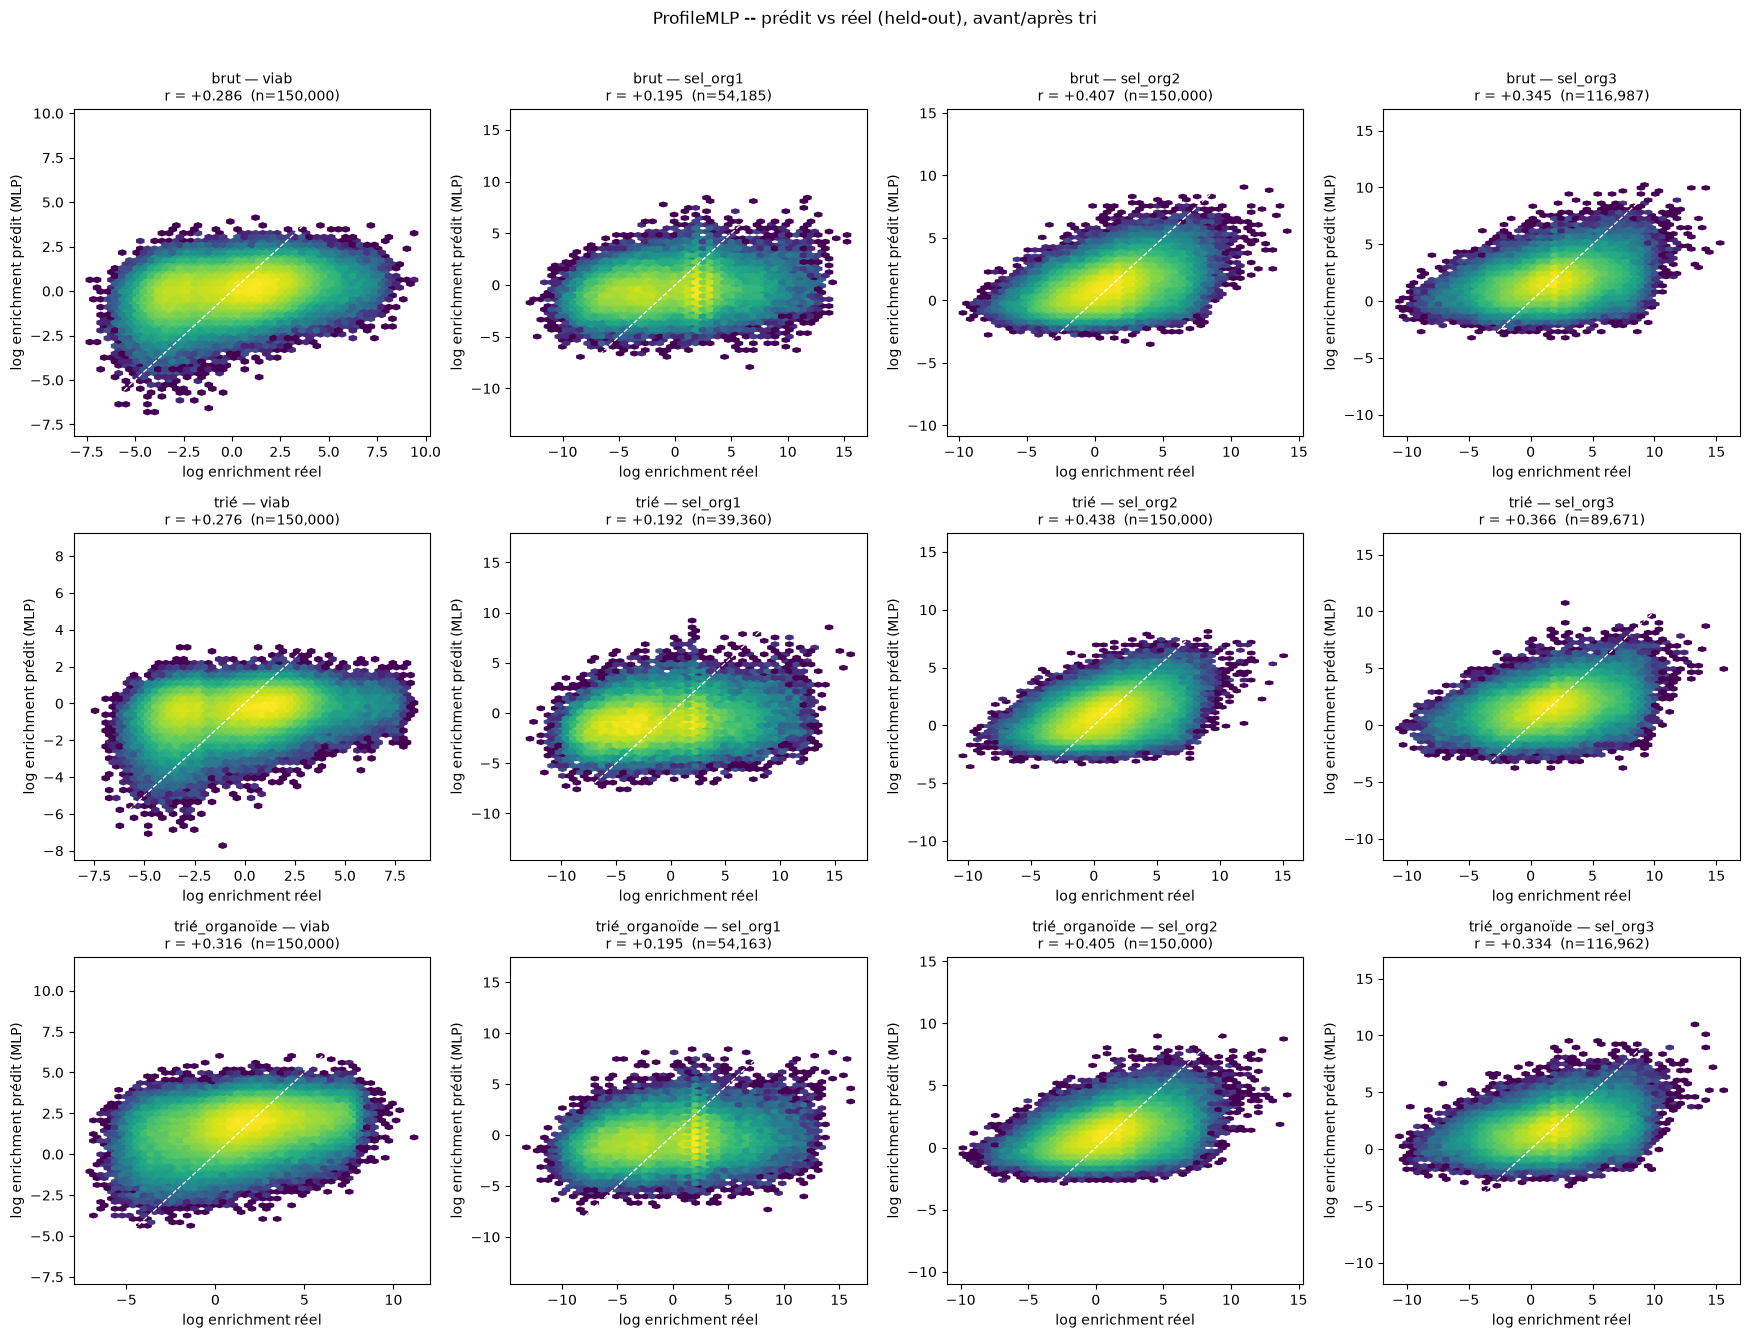

In [7]:
tags = list(datasets.keys())
names = list(targets.keys())

fig, axes = plt.subplots(len(tags), len(names), figsize=(4.4 * len(names), 4.4 * len(tags)))
for row, tag in enumerate(tags):
    for col, name in enumerate(names):
        ax = axes[row, col]
        res = results[(tag, name)]
        y, p = res["y_eval"], res["pred_eval"]
        ax.hexbin(y, p, gridsize=45, bins="log", mincnt=1, cmap="viridis")
        lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
        ax.plot([lo, hi], [lo, hi], "w--", lw=0.9)
        ax.set_title(f"{tag} — {name}\nr = {res['r']:+.3f}  (n={res['n_eval']:,})", fontsize=10)
        ax.set_xlabel("log enrichment réel")
        ax.set_ylabel("log enrichment prédit (MLP)")
fig.suptitle("ProfileMLP -- prédit vs réel (held-out), avant/après tri", y=1.01)
fig.tight_layout()
plt.show()

### 6. Recovery top-k%

`plot_topk_recovery` par combinaison (k=10% du held-out), puis un tableau récapitulatif de
`precision_at_k` pour plusieurs `k_frac`, avant vs après tri, pour situer l'effet du tri
séparément sur chaque cible.

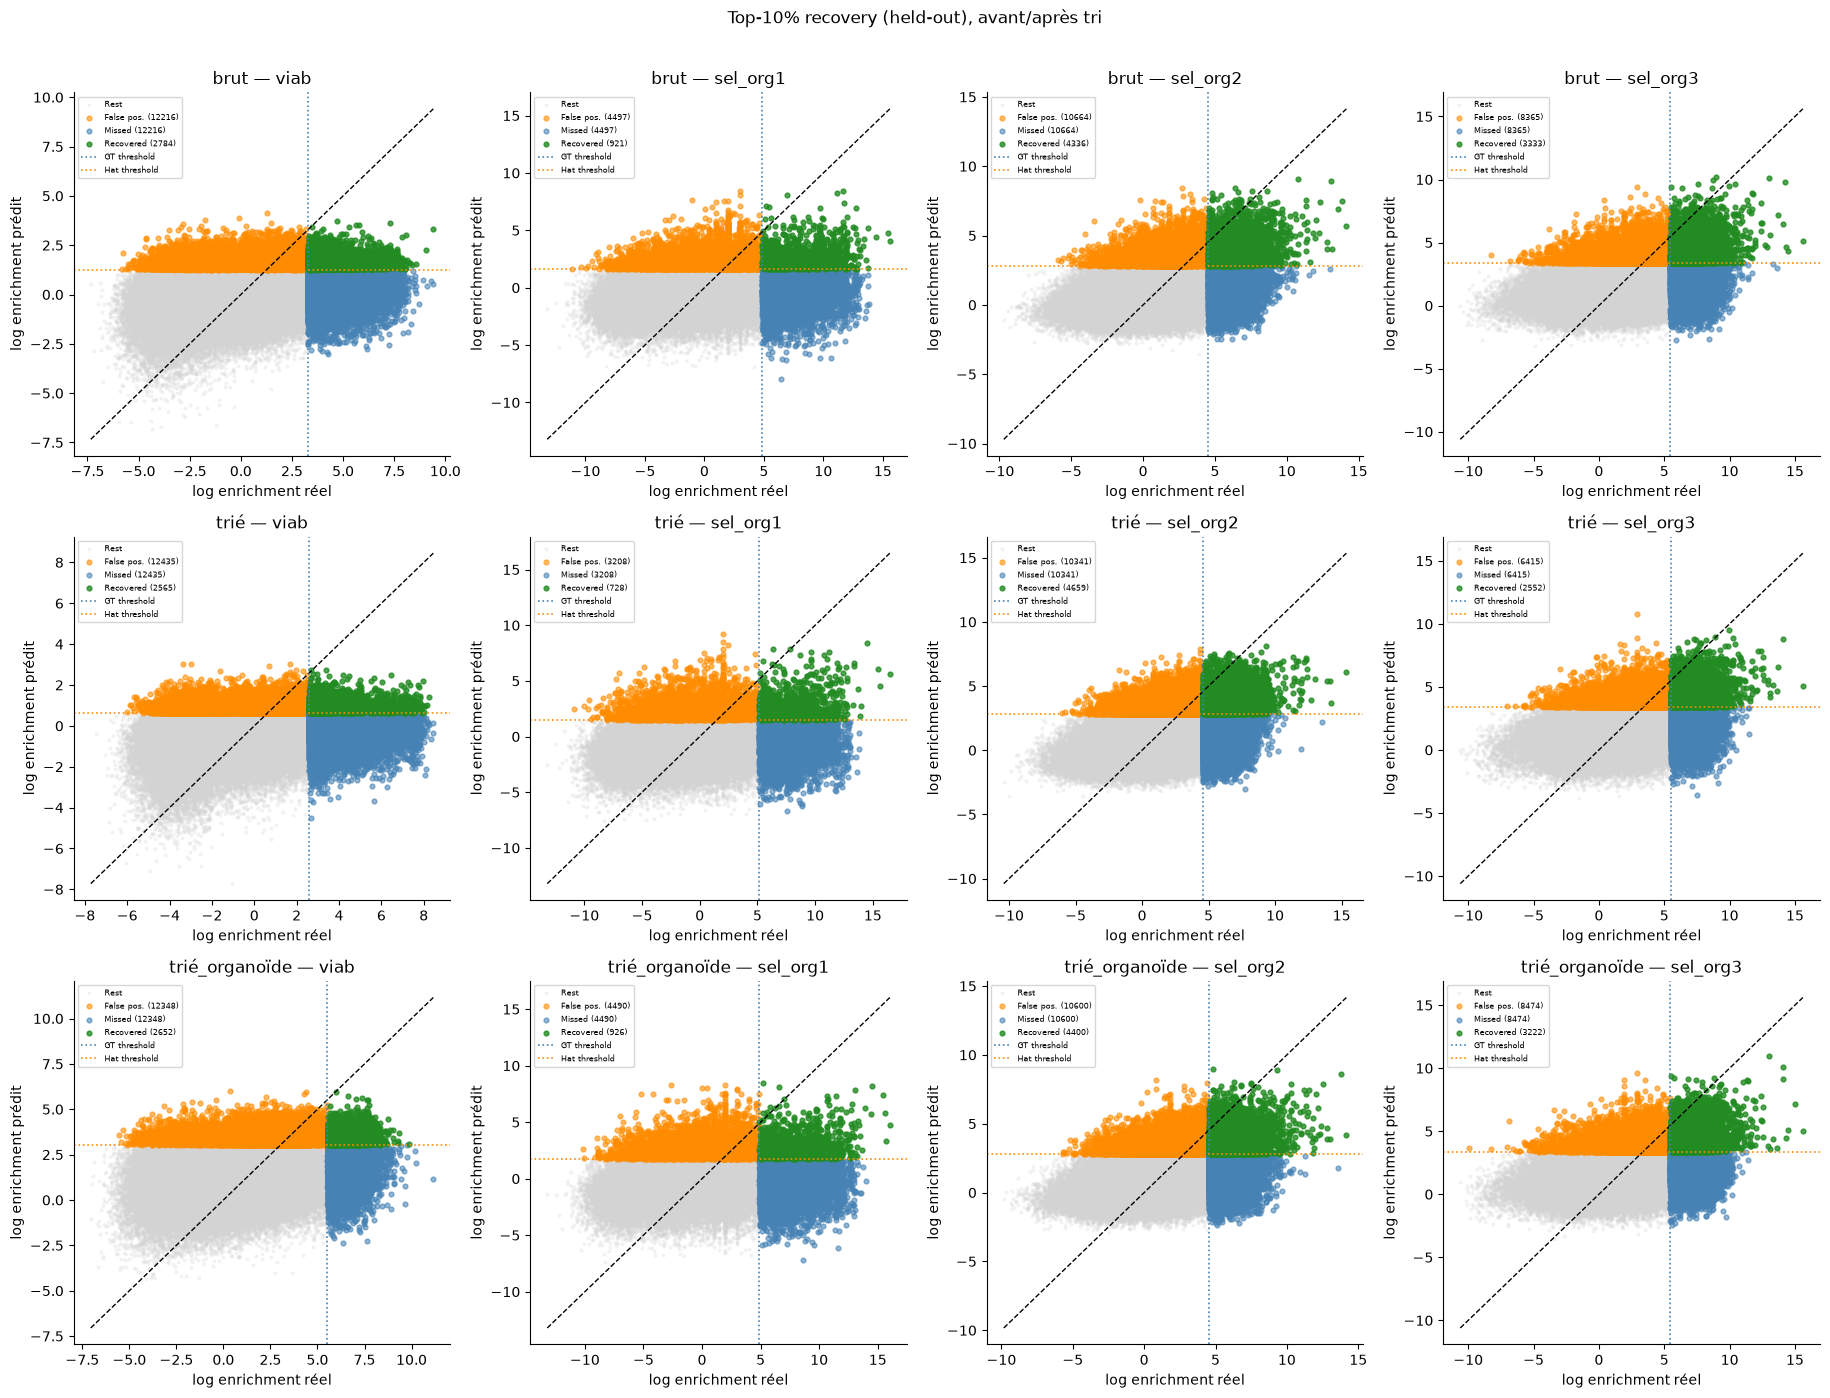

In [8]:
fig, axes = plt.subplots(len(tags), len(names), figsize=(4.6 * len(names), 4.6 * len(tags)))
for row, tag in enumerate(tags):
    for col, name in enumerate(names):
        ax = axes[row, col]
        res = results[(tag, name)]
        plot_topk_recovery(res["y_eval"], res["pred_eval"], k_frac=0.10,
                            xlabel="log enrichment réel", ylabel="log enrichment prédit",
                            title=f"{tag} — {name}", ax=ax)
        ax.legend(fontsize=6)
fig.suptitle("Top-10% recovery (held-out), avant/après tri", y=1.01)
fig.tight_layout()
plt.show()

In [9]:
rows = []
for tag in tags:
    for name in names:
        res = results[(tag, name)]
        row = {"CSV": tag, "cible": name, "n_held-out": res["n_eval"], "Pearson r": round(res["r"], 3)}
        for frac in (0.01, 0.05, 0.10, 0.20):
            row[f"top-{int(frac*100)}%"] = round(
                precision_at_k(res["y_eval"], res["pred_eval"], k_frac=frac), 3)
        rows.append(row)

summary = pd.DataFrame(rows).sort_values(["cible", "CSV"]).reset_index(drop=True)
summary

,CSV,cible,n_held-out,Pearson r,top-1%,top-5%,top-10%,top-20%
0,brut,sel_org1,54185,0.195,0.079,0.126,0.170,0.281
1,trié,sel_org1,39360,0.192,0.081,0.134,0.185,0.286
2,trié_organoïde,sel_org1,54163,0.195,0.072,0.121,0.171,0.281
3,brut,sel_org2,150000,0.407,0.151,0.223,0.289,0.398
4,trié,sel_org2,150000,0.438,0.157,0.238,0.311,0.418
5,trié_organoïde,sel_org2,150000,0.405,0.149,0.217,0.293,0.393
6,brut,sel_org3,116987,0.345,0.141,0.214,0.285,0.370
7,trié,sel_org3,89671,0.366,0.156,0.221,0.285,0.374
8,trié_organoïde,sel_org3,116962,0.334,0.129,0.210,0.275,0.362
9,brut,viab,150000,0.286,0.024,0.103,0.186,0.308


### 7. Effet du tri -- delta vs brut

`r`/`top-k%` de chaque CSV trié moins `brut`, par cible -- positif si ce tri améliore la
généralisation held-out du MLP sur cette cible, par rapport à aucun filtre.

In [10]:
pivot = summary.pivot(index="cible", columns="CSV")
metrics = ["Pearson r", "top-1%", "top-5%", "top-10%", "top-20%"]
other_tags = [t for t in tags if t != "brut"]

deltas = {}
for tag in other_tags:
    d = pd.DataFrame({m: pivot[(m, tag)] - pivot[(m, "brut")] for m in metrics})
    d.columns = [f"Δ {m}" for m in d.columns]
    deltas[tag] = d

delta = pd.concat(deltas, axis=1, names=["CSV (vs brut)", ""])
delta

CSV (vs brut)        trié                                        \
              Δ Pearson r Δ top-1% Δ top-5% Δ top-10% Δ top-20%   
cible                                                             
sel_org1           -0.003    0.002    0.008     0.015     0.005   
sel_org2            0.031    0.006    0.015     0.022     0.020   
sel_org3            0.021    0.015    0.007     0.000     0.004   
viab               -0.010   -0.001   -0.013    -0.015    -0.012   

CSV (vs brut) trié_organoïde                                        
                 Δ Pearson r Δ top-1% Δ top-5% Δ top-10% Δ top-20%  
cible                                                               
sel_org1               0.000   -0.007   -0.005     0.001     0.000  
sel_org2              -0.002   -0.002   -0.006     0.004    -0.005  
sel_org3              -0.011   -0.012   -0.004    -0.010    -0.008  
viab                   0.030    0.007    0.003    -0.009    -0.009